# CADE: reproducing the paper

This notebook reproduces the results in *CADE: Context-Aware Differentiable
Elastic Alignment for Time Series* (Holder, Qiu and Bagnall).

1. **CADE in practice.** The smooth between-gate, a soft alignment matrix, and a
   numerical check that the implemented gradient is correct.
2. **Averaging.** Table 1, from `results/averaging/`.
3. **Clustering.** Table 2 and the average-rank comparison (Figure 3), from
   `results/clustering/`.
4. **Classification.** The nearest-centroid comparison (Figure 4), from
   `results/classification/`.
5. **Dataset rebalancing (CADE-e-SMOTE).** Not yet in this repository (TODO).
6. **Re-running experiments.** How to regenerate the raw results, including the
   CricketX prototypes (Figure 2). Off by default because it needs the UCR archive
   and takes a long time.

Sections 2 to 4 only read the summary CSVs committed in `results/`, so they run in
seconds. Their statistics and figures come from aeon.
Everything needed for sections 1 to 5 is installed by `pip install -e ".[notebook]"`.

In [1]:
import itertools
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import rankdata

# Run from the repository root so relative result paths resolve.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
RESULTS = ROOT / "results"

GAMMAS = ["1.0", "0.1", "0.01", "0.001"]
LABELS = {  # result-file names -> names used in the paper
    "soft-DBA": "Soft-DBA",
    "soft-DBA2": "Soft-DBA2",
}
pd.set_option("display.precision", 4)
print("results found:", sorted(p.name for p in RESULTS.iterdir()))

results found: ['averaging', 'classification', 'clustering']


## 1. CADE in practice

### The smooth between-gate

MSM charges a split or merge the fixed penalty $c$ when $x$ lies between $y$ and
$z$, and adds a deviation term otherwise. CADE replaces that hard test with

$$g(x,y,z)=\tfrac12\Bigl(1-\frac{u}{\sqrt{u^2+\varepsilon}}\Bigr),\qquad u=(x-y)(x-z).$$

The plot shows $g$ for $y=-1$, $z=1$. With a very small $\varepsilon$ the gate is
almost a step function. Larger values give a wider transition region. Because
$u$ has squared data scale, $\varepsilon$ has fourth-power data scale.

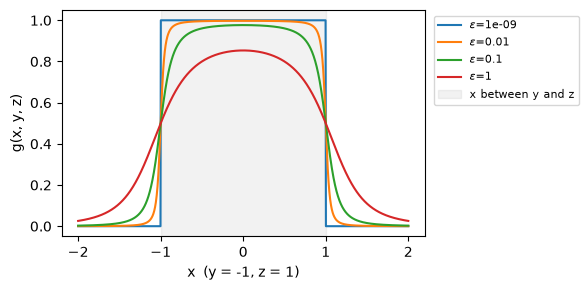

In [2]:
def between_gate(x, y, z, eps):
    u = (x - y) * (x - z)
    return 0.5 * (1.0 - u / np.sqrt(u * u + eps))


xs = np.linspace(-2, 2, 2001)
fig, ax = plt.subplots(figsize=(6, 3))
for eps in [1e-9, 1e-2, 1e-1, 1.0]:
    ax.plot(xs, between_gate(xs, -1.0, 1.0, eps), label=rf"$\varepsilon$={eps:g}")
ax.axvspan(-1, 1, color="grey", alpha=0.1, label="x between y and z")
ax.set_xlabel("x  (y = -1, z = 1)")
ax.set_ylabel("g(x, y, z)")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()

### Loss, alignment matrix and gradient (PyTorch backend)

We align a sine wave with a time-shifted copy. The CADE alignment matrix $E$
concentrates around the warping path. As $\gamma$ grows, the mass spreads
over more alignments. As with Soft-DTW, the soft minimum can make the value
negative for large $\gamma$, because it sums over many paths.

In [3]:
try:
    import torch

    from cade.torch import CADELoss, cade_alignment_matrix, cade_grad_x

    HAVE_TORCH = True
except ImportError:
    HAVE_TORCH = False
    print('PyTorch backend not installed: pip install -e ".[notebook]"')

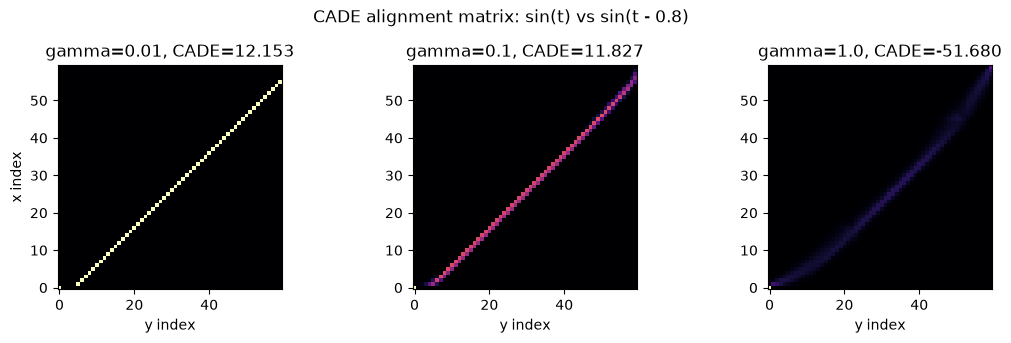

In [4]:
if HAVE_TORCH:
    t = np.linspace(0, 2 * np.pi, 60)
    x = torch.tensor(np.sin(t), dtype=torch.float64).reshape(1, 1, -1)
    y = torch.tensor(np.sin(t - 0.8), dtype=torch.float64).reshape(1, 1, -1)

    gammas = [0.01, 0.1, 1.0]
    fig, axes = plt.subplots(1, len(gammas), figsize=(11, 3.4))
    for ax, gamma in zip(axes, gammas):
        E, s = cade_alignment_matrix(x, y, c=1.0, gamma=gamma)
        ax.imshow(E[0].numpy(), origin="lower", cmap="magma")
        ax.set_title(f"gamma={gamma}, CADE={s.item():.3f}")
        ax.set_xlabel("y index")
    axes[0].set_ylabel("x index")
    fig.suptitle("CADE alignment matrix: sin(t) vs sin(t - 0.8)")
    fig.tight_layout()

The gradient from `cade_grad_x` is checked two ways on random pairs of series
with different lengths, in the spirit of the manuscript's gradient validation:

- against autograd through `CADELoss`;
- against central finite differences of the loss, with two step sizes $h$.

Finite differences need care near the gate's switching boundary. With the small
$\varepsilon$ used in the implementation, the gate changes very quickly there,
so a step of $h=10^{-6}$ can straddle the transition. In the table, that shows
up as a larger error on one pair (trial 2) that shrinks as $h$ gets smaller. It
is a limitation of the finite-difference check, not of the gradient.

In [5]:
def finite_difference(loss, x, y, h):
    fd = torch.zeros_like(x)
    for i in range(x.shape[-1]):
        xp, xm = x.clone(), x.clone()
        xp[0, 0, i] += h
        xm[0, 0, i] -= h
        fd[0, 0, i] = (loss(xp, y) - loss(xm, y)) / (2 * h)
    return fd


if HAVE_TORCH:
    rng = np.random.default_rng(123)
    rows = []
    for trial in range(10):
        m, n = rng.integers(5, 25, size=2)
        gamma = float(rng.choice([1.0, 0.5, 0.1, 0.05]))
        xt = torch.tensor(rng.normal(size=(1, 1, m)), dtype=torch.float64)
        yt = torch.tensor(rng.normal(size=(1, 1, n)), dtype=torch.float64)
        loss = CADELoss(c=1.0, gamma=gamma, reduction="sum")

        dx, _ = cade_grad_x(xt, yt, c=1.0, gamma=gamma)
        x_auto = xt.clone().requires_grad_(True)
        loss(x_auto, yt).backward()

        rows.append({
            "m": int(m), "n": int(n), "gamma": gamma,
            "max |grad|": dx.abs().max().item(),
            "vs autograd": (dx - x_auto.grad).abs().max().item(),
            "vs FD, h=1e-6": (dx - finite_difference(loss, xt, yt, 1e-6)).abs().max().item(),
            "vs FD, h=1e-8": (dx - finite_difference(loss, xt, yt, 1e-8)).abs().max().item(),
        })
    display(pd.DataFrame(rows).rename_axis("trial").style.format(
        {"max |grad|": "{:.2f}", "vs autograd": "{:.1e}", "vs FD, h=1e-6": "{:.1e}", "vs FD, h=1e-8": "{:.1e}"}
    ))

,m,n,gamma,max |grad|,vs autograd,"vs FD, h=1e-6","vs FD, h=1e-8"
trial,,,,,,,
0,5,18,0.100000,1.72,0.0e+00,3.5e-09,4.7e-07
1,6,12,1.000000,2.54,0.0e+00,1.6e-09,8.1e-08
2,23,8,0.100000,8.28,0.0e+00,2.2e-04,6.8e-07
3,11,14,1.000000,1.95,0.0e+00,5.2e-10,4.5e-08
4,16,23,0.050000,4.07,0.0e+00,4.3e-09,5.0e-07
5,10,14,1.000000,2.72,0.0e+00,2.5e-10,6.2e-08
6,8,12,0.100000,5.54,0.0e+00,5.7e-09,3.4e-07
7,21,13,1.000000,3.78,0.0e+00,1.6e-09,2.9e-07
8,8,22,1.000000,3.26,0.0e+00,1.8e-09,3.4e-07


## 2. Averaging (Table 1)

For each UCR dataset, 10 series are sampled from a random class and averaged,
with 10 repeats. Barycentres are always scored with the *hard* distance of the
reference geometry:

- **DTW geometry:** Soft-DTW barycentre vs DBA and SSG-DBA.
- **MSM geometry:** CADE-BA vs MBA and SSG-MBA.

Each cell is the percentage of datasets on which the soft method's mean loss is
lower than the baseline's. The first cell checks that every method and $\gamma$
has results for the same datasets, so all cells share one denominator.

In [6]:
from cade.evaluation import get_percentage_dataframe

for geometry in ["msm", "dtw"]:
    runs = pd.read_csv(RESULTS / "averaging" / f"{geometry}_final_average.csv")
    runs["gamma"] = runs["gamma"].fillna("-").astype(str)
    per_cell = runs.groupby(["method", "gamma"])["dataset"].nunique()
    repeats = runs.groupby(["dataset", "method", "gamma"]).size()
    print(f"{geometry.upper()}: datasets per method/gamma = {sorted(set(per_cell))}, "
          f"repeats per dataset = {sorted(set(repeats))}")

table1 = pd.concat(
    {
        "Soft-DTW, DTW loss": get_percentage_dataframe("dtw"),
        "CADE, MSM loss": get_percentage_dataframe("msm"),
    },
    axis=1,
)
table1.index.name = "gamma"
table1.round(1)

MSM: datasets per method/gamma = [109], repeats per dataset = [10]
DTW: datasets per method/gamma = [109], repeats per dataset = [10]


Soft-DTW, DTW loss         CADE, MSM loss        
                     DBA SSG-DBA            MBA SSG-MBA
gamma                                                  
1.0                  2.8    14.7            7.3    26.6
0.1                 48.6    49.5           94.5    96.3
0.01                86.2    78.9           97.2   100.0
0.001               93.6    83.5           97.2   100.0

The averaging results cover **109 datasets** for every method and $\gamma$, each
with 10 repeats. The three Pig datasets (PigAirwayPressure, PigArtPressure,
PigCVP) are not in the averaging results.

## 3. Clustering

### Table 2: soft averaging inside k-means

$k$-means (with $k$ equal to the number of classes) is run with CADE-BA and
Soft-DBA centroids, with the hard distance used for assignment. Each entry is the
percentage of datasets on which the soft variant reaches lower inertia than its
hard counterpart (MBA and DBA respectively). Ties count as not better.

**Not every run completed.** `inertia_values.csv` lists 112 datasets, but some
dataset, method and $\gamma$ combinations are empty. The gaps are concentrated in
the CADE-BA runs, especially $\gamma=1$. Many of them are on large or long
datasets, such as FordA/B, ElectricDevices, the Pig and Semg datasets, and
Phoneme. MBA is the only column with no gaps.

In [7]:
inertia = pd.read_csv(RESULTS / "clustering" / "inertia_values.csv").set_index("dataset")

coverage = pd.DataFrame({
    "present": inertia.notna().sum(),
    "missing": inertia.isna().sum(),
    "missing datasets": inertia.isna().apply(lambda col: ", ".join(inertia.index[col])),
})
coverage

,present,missing,missing datasets
DBA,109,3,"InlineSkate, NonInvasiveFetalECGThorax1, Phoneme"
MBA,112,0,
soft-DBA-hard-dist-gamma-1.0,106,6,"CinCECGTorso, FordA, FordB, Phoneme, SemgHandM..."
soft-DBA-hard-dist-gamma-0.1,106,6,"CinCECGTorso, EOGHorizontalSignal, MixedShapes..."
soft-DBA-hard-dist-gamma-0.01,103,9,"CinCECGTorso, EOGVerticalSignal, FordA, HandOu..."
soft-DBA-hard-dist-gamma-0.001,107,5,"CinCECGTorso, MixedShapesRegularTrain, MixedSh..."
CADE-BA-hard-dist-gamma-1.0,72,40,"CinCECGTorso, Computers, Earthquakes, ECG5000,..."
CADE-BA-hard-dist-gamma-0.1,94,18,"CinCECGTorso, Earthquakes, ElectricDevices, Fo..."
CADE-BA-hard-dist-gamma-0.01,99,13,"CinCECGTorso, ElectricDevices, FordA, FordB, P..."
CADE-BA-hard-dist-gamma-0.001,97,15,"CinCECGTorso, Earthquakes, ElectricDevices, Fo..."


If each cell only uses datasets where its own pair of runs completed, the
denominators differ from cell to cell: 94 to 105 datasets for the reported
$\gamma$ values. Percentages in
different rows and columns are then not directly comparable. Table 2 is
therefore computed over the **common set**: datasets where MBA, DBA and every
CADE-BA and Soft-DBA run for the reported $\gamma$ values are all present. As in
the paper, $\gamma = 1$ is excluded. Including it would shrink the common set to
69 datasets, because CADE-BA with $\gamma=1$ is missing on 40.
`cade/evaluation/_parse_output_files.py` prints the same table in LaTeX.

In [8]:
TABLE2_GAMMAS = ["0.1", "0.01", "0.001"]
FAMILIES = {"CADE-BA vs MBA": ("CADE-BA", "MBA"), "Soft-DBA vs DBA": ("soft-DBA", "DBA")}
table2_columns = [
    col
    for soft, base in FAMILIES.values()
    for col in [base] + [f"{soft}-hard-dist-gamma-{g}" for g in TABLE2_GAMMAS]
]
common = inertia[table2_columns].dropna()
print(f"common set: {len(common)} of {len(inertia)} datasets")


def better_than_hard(frame, soft, base):
    return pd.Series(
        {g: 100 * (frame[f"{soft}-hard-dist-gamma-{g}"] < frame[base]).mean()
         for g in TABLE2_GAMMAS}
    )


table2 = pd.DataFrame(
    {name: better_than_hard(common, soft, base) for name, (soft, base) in FAMILIES.items()}
)
table2.index.name = "gamma"
table2.round(1)

common set: 87 of 112 datasets


,CADE-BA vs MBA,Soft-DBA vs DBA
gamma,,
0.1,86.2,9.2
0.01,82.8,50.6
0.001,81.6,83.9


For comparison, the per-cell version below, where each cell uses its own
datasets, is what the earlier draft of Table 2 reported. The conclusions are the
same either way. CADE-BA beats MBA on most datasets at every $\gamma$, while
Soft-DBA only beats DBA consistently at the smallest $\gamma$. The percentages
move by up to about 5 points.

In [9]:
per_cell = {}
for name, (soft, base) in FAMILIES.items():
    for g in TABLE2_GAMMAS:
        col = f"{soft}-hard-dist-gamma-{g}"
        pair = inertia[[base, col]].dropna()
        per_cell[(name, "better (%)", g)] = 100 * (pair[col] < pair[base]).mean()
        per_cell[(name, "datasets", g)] = len(pair)
per_cell = pd.Series(per_cell).unstack(level=[0, 1]).reindex(TABLE2_GAMMAS)
per_cell.index.name = "gamma"
per_cell.style.format(
    lambda v: f"{v:.1f}" if v % 1 else f"{v:.0f}"
)

### Figure 3: comparison with $k$-AVG and $k$-Shape

The critical difference diagrams use `aeon.visualisation.plot_critical_difference`
with the settings used in the paper: $\alpha=0.1$, pairwise Wilcoxon signed-rank
tests and `correction="holm"`. aeon's procedure works like this:

- It runs a **Friedman test**. If that is not significant, all methods form a
  single clique.
- It runs **one-sided** Wilcoxon tests between each pair of methods, ordered by
  average rank.
- It compares every p-value with the fixed threshold $\alpha/(k-1)$.
- It builds cliques from the ranked list. Once method $i$ is significantly
  different from method $j$, it is also treated as different from every method
  ranked below $j$.

That last rule means a clique diagram can separate two methods whose *direct*
pairwise test is not significant. Each diagram is therefore followed by aeon's
pairwise p-values (`return_p_values=True`).

In [10]:
from aeon.benchmarking.stats import check_friedman
from aeon.visualisation import plot_critical_difference, plot_pairwise_scatter

ALPHA = 0.1
CADE_COLOUR = "#C0392B"


def load_scores(folder, fname):
    return pd.read_csv(RESULTS / folder / fname, index_col=0).rename(columns=LABELS)


def critical_difference(scores, title):
    labels = list(scores.columns)
    fig, ax, p_values = plot_critical_difference(
        scores.to_numpy(),
        labels,
        highlight={label: CADE_COLOUR for label in labels if label.startswith("CADE")},
        alpha=ALPHA,
        test="wilcoxon",
        correction="holm",
        return_p_values=True,
    )
    fig.suptitle(f"{title} ({len(scores)} datasets)")
    plt.show()

    # aeon orders the p-value matrix by average rank (best first).
    ranks = rankdata(-scores.to_numpy(), axis=1)
    order = np.array(labels)[np.argsort(ranks.mean(axis=0))]
    threshold = ALPHA / (len(labels) - 1)
    print(f"Friedman p = {check_friedman(ranks):.2e}; mean scores:",
          scores.mean().round(4).to_dict())
    return pd.DataFrame(
        [
            {
                "higher rank": order[i],
                "lower rank": order[j],
                "mean score diff": scores[order[i]].mean() - scores[order[j]].mean(),
                "one-sided p": p_values[i, j],
                f"p < {threshold:.3f}": p_values[i, j] < threshold,
            }
            for i, j in itertools.combinations(range(len(labels)), 2)
        ]
    )

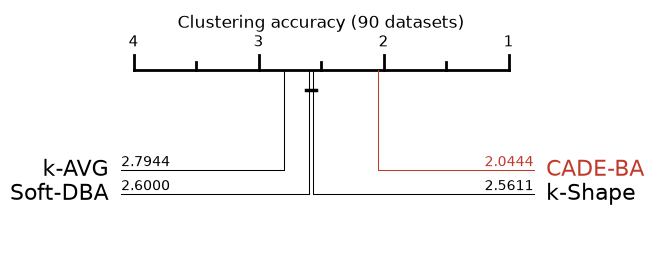

Friedman p = 6.42e-04; mean scores: {'k-AVG': 0.5344, 'k-Shape': 0.5662, 'Soft-DBA': 0.5588, 'CADE-BA': 0.5817}


,higher rank,lower rank,mean score diff,one-sided p,p < 0.033
0,CADE-BA,k-Shape,0.0155,1.8960e-03,True
1,CADE-BA,Soft-DBA,0.0229,5.2323e-02,False
2,CADE-BA,k-AVG,0.0473,1.2004e-05,True
3,k-Shape,Soft-DBA,0.0074,4.1225e-01,False
4,k-Shape,k-AVG,0.0318,1.5975e-02,True
5,Soft-DBA,k-AVG,0.0244,2.0731e-02,True


In [11]:
critical_difference(load_scores("clustering", "clacc_mean.csv"), "Clustering accuracy")

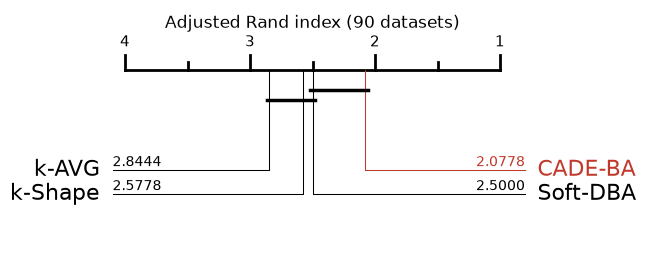

Friedman p = 8.62e-04; mean scores: {'k-AVG': 0.2097, 'k-Shape': 0.2506, 'Soft-DBA': 0.2422, 'CADE-BA': 0.2747}


,higher rank,lower rank,mean score diff,one-sided p,p < 0.033
0,CADE-BA,Soft-DBA,0.0325,8.5963e-02,False
1,CADE-BA,k-Shape,0.0240,1.6025e-03,True
2,CADE-BA,k-AVG,0.0649,2.4990e-06,True
3,Soft-DBA,k-Shape,-0.0084,3.3261e-01,False
4,Soft-DBA,k-AVG,0.0325,3.6129e-02,False
5,k-Shape,k-AVG,0.0409,1.3951e-02,True


In [12]:
critical_difference(load_scores("clustering", "ari_mean.csv"), "Adjusted Rand index")

CADE-BA has the best average rank and mean score on both measures, and is
significantly better than $k$-AVG and $k$-Shape in direct tests. Against Soft-DBA
on clustering accuracy, the diagram separates the two methods only through
clique propagation. The direct one-sided test gives $p \approx 0.05$, which is
above the $\alpha/(k-1)$ threshold. AMI and NMI results are also in
`results/clustering/`.

**Dataset count.** The accuracy, ARI, AMI and NMI files have no missing values,
but they cover 90 datasets rather than 112. The 22 datasets not included are
listed below.

In [13]:
clustering_datasets = set(load_scores("clustering", "clacc_mean.csv").index)
for name in ["ari_mean.csv", "ami_mean.csv", "nmi_mean.csv"]:
    assert set(load_scores("clustering", name).index) == clustering_datasets
not_included = sorted(set(inertia.index) - clustering_datasets)
print(f"{len(clustering_datasets)} datasets; {len(not_included)} not included:")
print(", ".join(not_included))

90 datasets; 22 not included:
CinCECGTorso, Earthquakes, ElectricDevices, FordA, FordB, HandOutlines, MixedShapesRegularTrain, MixedShapesSmallTrain, NonInvasiveFetalECGThorax1, NonInvasiveFetalECGThorax2, Phoneme, PigAirwayPressure, PigArtPressure, PigCVP, RefrigerationDevices, SemgHandGenderCh2, SemgHandMovementCh2, SemgHandSubjectCh2, ShapeletSim, SmallKitchenAppliances, TwoPatterns, UWaveGestureLibraryAll


## 4. Classification (Figure 4)

The nearest-centroid classifier uses one barycentre per class, fitted on the
training data:

- **Soft-DBA / CADE-BA:** the soft function forms the centroids *and* finds the
  nearest centroid.
- **Soft-DBA2 / CADE-BA2:** the soft function forms the centroids; the hard
  distance (DTW or MSM) finds the nearest centroid.

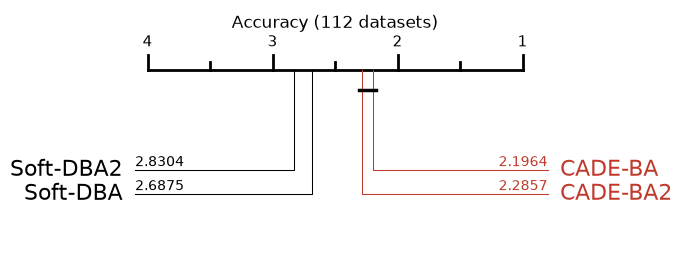

Friedman p = 9.24e-05; mean scores: {'Soft-DBA': 0.6454, 'Soft-DBA2': 0.6437, 'CADE-BA': 0.657, 'CADE-BA2': 0.6608}


,higher rank,lower rank,mean score diff,one-sided p,p < 0.033
0,CADE-BA,CADE-BA2,-0.0038,0.6352,False
1,CADE-BA,Soft-DBA,0.0116,0.0168,True
2,CADE-BA,Soft-DBA2,0.0132,0.0105,True
3,CADE-BA2,Soft-DBA,0.0154,0.0091,True
4,CADE-BA2,Soft-DBA2,0.0170,0.0066,True
5,Soft-DBA,Soft-DBA2,0.0016,0.0024,True


In [14]:
critical_difference(load_scores("classification", "accuracy_mean.csv"), "Accuracy")

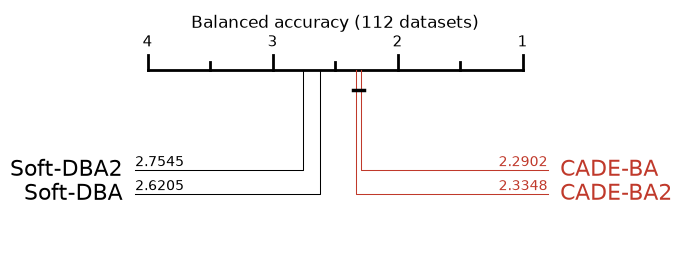

Friedman p = 1.15e-02; mean scores: {'Soft-DBA': 0.6407, 'Soft-DBA2': 0.6389, 'CADE-BA': 0.6525, 'CADE-BA2': 0.6554}


,higher rank,lower rank,mean score diff,one-sided p,p < 0.033
0,CADE-BA,CADE-BA2,-0.0029,0.5621,False
1,CADE-BA,Soft-DBA,0.0118,0.0108,True
2,CADE-BA,Soft-DBA2,0.0136,0.0067,True
3,CADE-BA2,Soft-DBA,0.0147,0.0098,True
4,CADE-BA2,Soft-DBA2,0.0165,0.0074,True
5,Soft-DBA,Soft-DBA2,0.0018,0.0016,True


In [15]:
critical_difference(load_scores("classification", "balacc_mean.csv"), "Balanced accuracy")

Pairwise accuracy for each variant, drawn with `aeon.visualisation.plot_pairwise_scatter`.

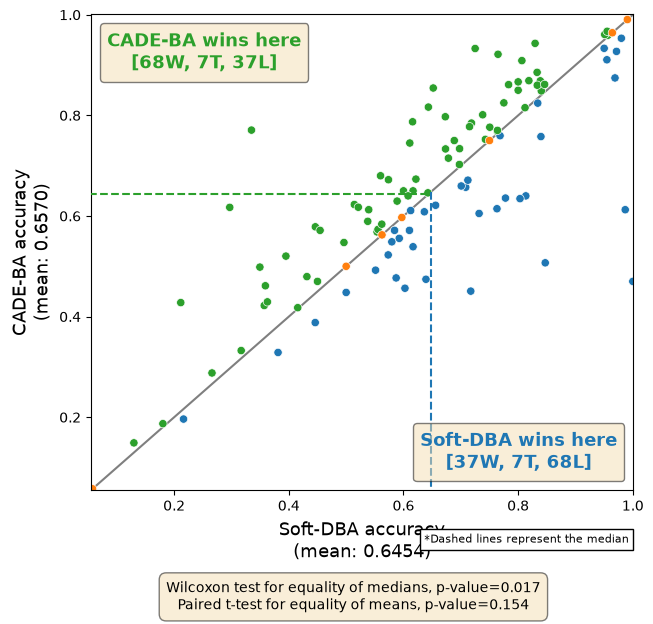

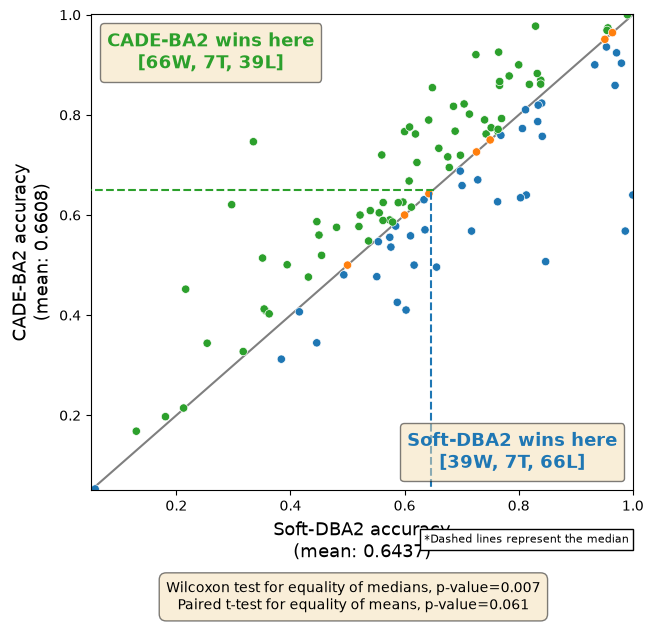

In [16]:
accuracy = load_scores("classification", "accuracy_mean.csv")
for cade, soft in [("CADE-BA", "Soft-DBA"), ("CADE-BA2", "Soft-DBA2")]:
    fig, ax = plot_pairwise_scatter(
        accuracy[cade], accuracy[soft], cade, soft, metric="accuracy", figsize=(7, 7)
    )
    plt.show()

## 5. Dataset rebalancing (CADE-e-SMOTE)

> **TODO.** The CADE-e-SMOTE code, the 60 imbalanced UCR problems, the HIVE-COTE
> 2.0 results (Table 3, Figures 5 and 6) and the $\gamma$ sensitivity analysis
> are not yet in this repository. This section will be filled in once they are
> added.

## 6. Re-running the experiments

The summary CSVs above were produced by the scripts in `cade/experiments/`.
Re-running them requires:

- the UCR archive locally, with `DATASET_PATH` and `RESULT_PATH` set in `.env`
  (see `.env.example`);
- `pip install -e ".[experiments]"`, which installs the aeon development branch
  with the Numba soft MSM distance and soft barycentre averaging. Released aeon
  includes Soft-DTW but not the soft MSM distance.

Full runs over 112 datasets are intended for a compute cluster. The cell below
regenerates the CricketX prototypes (Figure 2) and is the quickest end-to-end
check. Set `RUN_EXPERIMENTS = True` to run it.

In [17]:
RUN_EXPERIMENTS = False

if RUN_EXPERIMENTS:
    from aeon.clustering.averaging import elastic_barycenter_average

    from cade.experiments._utils import (
        get_averaging_params,
        load_and_validate_env,
        load_dataset_from_file,
    )

    env = load_and_validate_env()
    X, y, _, _ = load_dataset_from_file(
        "CricketX", Path(env["DATASET_PATH"]), normalize=True, combine_test_train=False
    )
    X_class = X[y == "12"][:, 0, :]

    configs = {
        "CADE (γ=0.001)": ("soft", {"gamma": 0.001, "distance": "soft_msm"}),
        "Soft-DTW (γ=0.001)": ("soft", {"gamma": 0.001, "distance": "soft_dtw"}),
        "MBA": ("petitjean", {"distance": "msm"}),
        "SSG-MBA": ("subgradient", {"distance": "msm"}),
    }
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    for ax, (label, (method, params)) in zip(axes.ravel(), configs.items()):
        bary = elastic_barycenter_average(
            X_class, method=method, random_state=1,
            **{**get_averaging_params(method), **params},
        )
        ax.plot(X_class.T, color="black", lw=0.5, alpha=0.3)
        ax.plot(np.asarray(bary).reshape(-1), color="C3", lw=2.5)
        ax.set_title(label)
    fig.suptitle("Class 12 averages on CricketX")
    fig.tight_layout()
else:
    print("Skipped. Set RUN_EXPERIMENTS = True to regenerate Figure 2.")

Skipped. Set RUN_EXPERIMENTS = True to regenerate Figure 2.


Command-line entry points for the full experiments (see the README for details):

```bash
python -m cade.experiments._averaging_experiment <distances_csv> <averaging_method> <repeats> <combine_test_train>
python -m cade.experiments._clustering_experiment <dataset> <model> <combine_test_train> <dataset_path> <results_path> [gamma]
python -m cade.experiments._classification_experiment <dataset> <model> <dataset_path> <results_path> [gamma]
```